<a href="https://colab.research.google.com/github/DaniaZehra/QC_Project/blob/main/qc_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QGRU-WGAN for Video Anomaly Detection — UCSD Ped2

Adaptation of *Quantum Gated Recurrent GAN with Gaussian Uncertainty for Network Anomaly Detection* (Hammami et al., 2025) to the **UCSD Pedestrian 2** video anomaly detection dataset.

**Key changes from the original paper:**
- Raw video frames → ResNet-18 CNN encoder → 16-dim latent vectors (replaces CSV sensor features)
- Consecutive frame windows replace sliding time-series windows
- Frame-level anomaly labels replace HAI attack labels
- GPU acceleration throughout (encoder, training, inference)
- QGRU-WGAN architecture, HQL, SuDaI, and anomaly scoring pipeline are **unchanged**

**Pipeline overview:**
```
UCSD Ped2 frames
  → ResNet-18 encoder (GPU)      # frame → 16-dim vector
  → sliding windows (W=3)         # (N, 3, 16) — identical shape to paper
  → K-Means downsampling          # compact representative training set
  → QGRU-WGAN training            # quantum generator + Wasserstein critic
  → two-stage anomaly scoring     # interval gate → critic + reconstruction
```

## 0. Install dependencies

In [2]:
!pip install pennylane pennylane-lightning -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 14.2 MB/s eta 0:00:00


In [3]:
# Install kaggle API
!pip install -q kaggle

In [4]:
import os

# Set your Kaggle API credentials
os.environ['KAGGLE_USERNAME'] = "daniazehra"
os.environ['KAGGLE_KEY'] = "KGAT_f3090340acd62ff2c9d22afb2c0ff055"

In [5]:
# Download the dataset
!kaggle datasets download -d karthiknm1/ucsd-anomaly-detection-dataset

# Unzip it
!unzip ucsd-anomaly-detection-dataset.zip -d dataset_content/

Streaming output truncated to the last 5000 lines.
  inflating: dataset_content/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/043.bmp  
  inflating: dataset_content/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/044.bmp  
  inflating: dataset_content/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/045.bmp  
  inflating: dataset_content/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/046.bmp  
  inflating: dataset_content/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/047.bmp  
  inflating: dataset_content/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/048.bmp  
  inflating: dataset_content/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/049.bmp  
  inflating: dataset_content/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/050.bmp  
  inflating: dataset_content/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/051.bmp  
  inflating: dataset_content/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/052.bmp  
  inflating: dataset_content/UCSD_Anomaly_Dataset

## 1. Imports & configuration

In [6]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pennylane as qml
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from PIL import Image
import torchvision.transforms as T
import torchvision.models as models
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ── Device setup ──────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

DATA_DIR = "dataset_content/UCSD_Anomaly_Dataset.v1p2/UCSDped2"

# ── Hyperparameters (SMOKE TEST TRIMMED) ─────────────────────────────────────
FEATURE_DIM   = 32 # Increased from 16
WINDOW_SIZE   = 7  # Increased from 3
VAL_FRACTION  = 0.5
HIDDEN_DIM    = 16
TOP_K         = 3
KAPPA         = 2.0
THRESH_K      = 1.5
LAMBDA_KL     = 0.05
LAMBDA_GP     = 1.0
BATCH_SIZE    = 8
LR_CRITIC     = 5e-5
LR_GENERATOR  = 1e-4
CRITIC_STEPS  = 5
CRITIC_CLIP_VAL = 0.01 # New hyperparameter for weight clipping
RANDOM_STATE  = 42
N_CLUSTERS    = 50
N_EPOCHS      = 4
ANSATZ_DEPTH  = 3
N_QUBITS      = 4
SUDAI_LAYERS  = 1
CRITIC_CLIP_VAL = 0.01

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

Using device: cpu


In [7]:
class STEQuantumFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, h_gpu, qnode):
        # Run VQC on CPU (PennyLane requirement)
        h_cpu = h_gpu.detach().cpu()
        q_out = torch.stack(
            [qnode(h_cpu[i]) for i in range(h_cpu.shape[0])], dim=0
        )
        ctx.save_for_backward(h_gpu)
        ctx.q_out_shape = q_out.shape
        return q_out.to(h_gpu.device)

    @staticmethod
    def backward(ctx, grad_output):
        (h_gpu,) = ctx.saved_tensors
        # Straight-through: pass grad directly back through the quantum op
        # Pad/trim to match h_gpu's shape if n_qubits != vqc_in_dim
        grad_h = grad_output
        if grad_output.shape[-1] != h_gpu.shape[-1]:
            if grad_output.shape[-1] < h_gpu.shape[-1]:
                pad = torch.zeros(
                    *grad_output.shape[:-1],
                    h_gpu.shape[-1] - grad_output.shape[-1],
                    device=h_gpu.device
                )
                grad_h = torch.cat([grad_output, pad], dim=-1)
            else:
                grad_h = grad_output[..., :h_gpu.shape[-1]]
        return grad_h, None  # None for qnode (not a tensor)

In [8]:
MODEL_NAME = "vit_b_16" # Set the backbone model: "resnet50", "vit_b_16", or "vit_b_32"

# Define the frame transformation required for pre-trained models
FRAME_TRANSFORM = T.Compose([
    T.Resize((224, 224)), # ViT models typically expect 224x224 input
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # ImageNet normalization
])

# Initialize quantum devices for HybridQuantumLayer
dev_g = qml.device("default.qubit", wires=N_QUBITS)
dev_c = qml.device("default.qubit", wires=N_QUBITS)
print("Global MODEL_NAME, FRAME_TRANSFORM, and quantum devices 'dev_g' and 'dev_c' initialized.")

Global MODEL_NAME, FRAME_TRANSFORM, and quantum devices 'dev_g' and 'dev_c' initialized.


In [9]:
import pennylane as qml
from pennylane import numpy as pnp

class QuantumEmbedding:
    """Flexible embedding strategies for HQL"""

    def __init__(self, n_qubits, method="angle", feature_dim=16):
        self.n_qubits = n_qubits
        self.method = method
        self.feature_dim = feature_dim

    def embed(self, x):
        """x: tensor of shape (batch, feature_dim)"""
        if self.method == "angle":
            # Current paper style
            for i in range(self.feature_dim):
                qml.RY(pnp.arctan(x[:, i % len(x[0])]), wires=i % self.n_qubits)
                # Optional: add RX or RZ for more expressivity

        elif self.method == "double_angle":
            # Encode two features per qubit
            for i in range(0, self.feature_dim, 2):
                q = i // 2 % self.n_qubits
                if i < self.feature_dim:
                    qml.RY(2 * pnp.arctan(x[:, i]), wires=q)   # or use arcsin
                if i+1 < self.feature_dim:
                    qml.RZ(2 * pnp.arctan(x[:, i+1]), wires=q)

        elif self.method == "phase":
            # Normalize + phase encoding
            norms = pnp.linalg.norm(x, axis=1, keepdims=True) + 1e-8
            x_norm = x / norms
            for i in range(self.feature_dim):
                q = i % self.n_qubits
                qml.RZ(pnp.arctan2(x[:, i], 1e-8), wires=q)  # or use angle

        elif self.method == "amplitude":
            # Requires exactly 2**n_qubits features (pad/trim)
            target_dim = 2 ** self.n_qubits
            if self.feature_dim != target_dim:
                # Pad with zeros or project
                padded = pnp.zeros((x.shape[0], target_dim))
                padded[:, :self.feature_dim] = x[:, :self.feature_dim]
                x = padded
            qml.AmplitudeEmbedding(x, wires=range(self.n_qubits), normalize=True, pad_with=0.0)

In [10]:
class HybridQuantumLayer(nn.Module):
    def __init__(self, in_dim, out_dim, n_qubits, device_qnode, method="angle"):
        super().__init__()
        self.n_qubits = n_qubits
        self.method = method
        self.ansatz_depth = ANSATZ_DEPTH
        self.sudai_layers = SUDAI_LAYERS
        self.feature_dim = out_dim
        vqc_in_dim = n_qubits * self.sudai_layers
        self.pre = nn.Linear(in_dim, vqc_in_dim)

        self.embedding_helper = QuantumEmbedding(n_qubits, method=method, feature_dim=vqc_in_dim)

        @qml.qnode(device_qnode, interface="torch", diff_method="parameter-shift")
        def circuit(inputs, weights):
            self.embedding_helper.embed(inputs.reshape(1, -1))
            for layer in range(self.ansatz_depth):
                for q in range(n_qubits):
                    qml.RZ(weights[layer, q, 0], wires=q)
                    qml.RX(weights[layer, q, 1], wires=q)
                for q in range(n_qubits - 1):
                    qml.CNOT(wires=[q, q + 1])
                qml.CNOT(wires=[n_qubits - 1, 0])
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        weight_shape = {"weights": (self.ansatz_depth, n_qubits, 2)}
        self.qnode = qml.qnn.TorchLayer(circuit, weight_shape)
        self.post = nn.Linear(n_qubits, out_dim)

    # Custom Autograd Function for Straight-Through Estimator
    class StraightThroughDetach(torch.autograd.Function):
        @staticmethod
        def forward(ctx, x):
            # In the forward pass, simply detach and move to CPU
            return x.detach().cpu()

        @staticmethod
        def backward(ctx, grad_output):
            # In the backward pass, pass the gradient through as if detach() didn't happen
            return grad_output.to(DEVICE)

    def forward(self, x):
      h = torch.tanh(self.pre(x))
      q_out = STEQuantumFunction.apply(h, self.qnode)  # replaces detach().cpu() pattern
      return self.post(q_out)

## 2. Frame encoder (ResNet-18 → 16-dim latent vectors)

Replaces the CSV feature columns from the paper. Each video frame is mapped to a 16-dimensional vector — the same dimensionality as the paper's `TOP_K_FEATURES = 16`. After this cell the data is structurally identical to the HAI pipeline.

In [11]:
class FrameEncoder(nn.Module):
    def __init__(self, out_dim: int = 16, freeze_backbone: bool = True):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        backbone.fc = nn.Identity()
        self.resnet_backbone = backbone

        # This head will be overwritten during the experiment with specific methods
        self.hql_head = nn.Sequential(
            nn.Linear(2048, HIDDEN_DIM),
            nn.ReLU(),
            HybridQuantumLayer(HIDDEN_DIM, out_dim, N_QUBITS,dev_g, method='angle')
        )

        if freeze_backbone:
            for p in self.resnet_backbone.parameters():
                p.requires_grad = False

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.resnet_backbone(x)
        features = torch.flatten(features, 1)
        return self.hql_head(features)

def encode_folder(folder, encoder, transform, batch_size=64):
    frame_paths = sorted(glob.glob(os.path.join(folder, '*.tif')) + glob.glob(os.path.join(folder, '*.png')) + glob.glob(os.path.join(folder, '*.jpg')))
    all_feats = []
    encoder.eval()
    with torch.no_grad():
        for i in range(0, len(frame_paths), batch_size):
            batch_paths = frame_paths[i : i + batch_size]
            imgs = torch.stack([transform(Image.open(p).convert('RGB')) for p in batch_paths]).to(DEVICE)
            feats = encoder(imgs)
            all_feats.append(feats.cpu().numpy())
    return np.concatenate(all_feats, axis=0)

print('FrameEncoder updated with Quantum Head.')

FrameEncoder updated with Quantum Head.


In [12]:
# class FrameEncoder(nn.Module):
#     def __init__(self, out_dim: int = 16, freeze_backbone: bool = True):
#         super().__init__()

#         global MODEL_NAME # Access the global variable

#         if MODEL_NAME == "resnet50":
#             backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
#             backbone.fc = nn.Identity() # Remove the final classification layer
#             self.net = backbone
#             feature_input_dim = 2048 # Output of ResNet50 before final FC
#         elif MODEL_NAME == "vit_b_16":
#             weights = models.ViT_B_16_Weights.IMAGENET1K_V1
#             self.net = models.vit_b_16(weights=weights)
#             # Replace ViT's default head with a projection to the desired latent dim
#             self.net.heads = nn.Sequential(
#                 nn.Linear(self.net.heads.head.in_features, 64),
#                 nn.ReLU(),
#                 nn.Linear(64, out_dim) # Project to out_dim
#             )
#             feature_input_dim = out_dim # Output of the custom ViT head
#         elif MODEL_NAME == "vit_b_32":
#             weights = models.ViT_B_32_Weights.IMAGENET1K_V1
#             self.net = models.vit_b_32(weights=weights)
#             # Replace ViT's default head with a projection to the desired latent dim
#             self.net.heads = nn.Sequential(
#                 nn.Linear(self.net.heads.head.in_features, 64),
#                 nn.ReLU(),
#                 nn.Linear(64, out_dim) # Project to out_dim
#             )
#             feature_input_dim = out_dim # Output of the custom ViT head
#         else:
#             raise ValueError(f"Unsupported MODEL_NAME: {MODEL_NAME}")

#         # This head will be overwritten during the experiment with specific methods.
#         # It's an initial setup, with the first Linear layer adapting to the backbone's output.
#         self.hql_head = nn.Sequential(
#             nn.Linear(feature_input_dim, HIDDEN_DIM),
#             nn.ReLU(),
#             HybridQuantumLayer(HIDDEN_DIM, out_dim, N_QUBITS, ANSATZ_DEPTH, SUDAI_LAYERS, dev_g, method='angle')
#         )

#         if freeze_backbone:
#             if MODEL_NAME == "resnet50":
#                 for p in self.net.parameters():
#                     p.requires_grad = False
#             elif MODEL_NAME in ["vit_b_16", "vit_b_32"]:
#                 # Freeze most layers, fine-tune head + last few blocks if needed
#                 for name, param in self.net.named_parameters():
#                     # Freeze everything except the new 'heads' and potentially some final encoder blocks
#                     if "heads" not in name and "encoder.layers" not in name:
#                         param.requires_grad = False

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         features = self.net(x)
#         # ResNet needs explicit flattening if fc was Identity. ViT's custom head outputs flattened features.
#         if MODEL_NAME == "resnet50":
#             features = torch.flatten(features, 1)
#         return self.hql_head(features)

# print(f"FrameEncoder defined with backbone: {MODEL_NAME}.")

## 3. Load & encode UCSD Ped2 frames

In [13]:
print("=" * 60)
print("STEP 1 — Loading & encoding (RE-INITIALIZED)")
print("=" * 60)

# Define the load_gt_masks function to load ground truth masks from image files
def load_gt_masks(folder):
    mask_paths = sorted(glob.glob(os.path.join(folder, '*.bmp')) + \
                        glob.glob(os.path.join(folder, '*.png')) + \
                        glob.glob(os.path.join(folder, '*.jpg')) + \
                        glob.glob(os.path.join(folder, '*.tif')))
    all_masks = []
    for p in mask_paths:
        # Load image, convert to grayscale
        mask = np.array(Image.open(p).convert('L'))
        # Determine if any pixel in the mask indicates an anomaly (value > 0)
        # This converts the 2D mask into a single 0 or 1 label for the frame
        all_masks.append(np.any(mask > 0).astype(np.float32))
    # Concatenate into a 1D array of frame-level labels
    return np.array(all_masks) if all_masks else np.array([])

# Re-instantiate the encoder to use the fresh quantum devices
encoder = FrameEncoder(out_dim=FEATURE_DIM, freeze_backbone=True).to(DEVICE)

train_dir = os.path.join(DATA_DIR, "Train")
test_dir  = os.path.join(DATA_DIR, "Test")

train_clip_dirs = sorted([d for d in glob.glob(os.path.join(train_dir, "Train*")) if os.path.isdir(d)])[:16]
print(f"Using {len(train_clip_dirs)} training clips")

train_features_list = []
for clip_dir in train_clip_dirs:
    feats = encode_folder(clip_dir, encoder, FRAME_TRANSFORM)
    train_features_list.append(feats)
    print(f"  {os.path.basename(clip_dir)} encoded.")

train_features = np.concatenate(train_features_list, axis=0)

test_clip_dirs = sorted([d for d in glob.glob(os.path.join(test_dir, "Test*")) if os.path.isdir(d) and "_gt" not in d])[:10]
test_features_list = []
test_labels_list   = []

for clip_dir in test_clip_dirs:
    gt_dir = clip_dir + "_gt"
    feats  = encode_folder(clip_dir, encoder, FRAME_TRANSFORM)
    labels = load_gt_masks(gt_dir) if os.path.isdir(gt_dir) else np.zeros(len(feats))

    min_len = min(len(feats), len(labels))
    test_features_list.append(feats[:min_len])
    test_labels_list.append(labels[:min_len])

test_features = np.concatenate(test_features_list, axis=0)
test_labels   = np.concatenate(test_labels_list,   axis=0)
print(f"Total training frames: {train_features.shape}")
print(f"Total test frames: {test_features.shape}")

STEP 1 — Loading & encoding (RE-INITIALIZED)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 135MB/s]


Using 16 training clips
  Train001 encoded.
  Train002 encoded.
  Train003 encoded.
  Train004 encoded.
  Train005 encoded.
  Train006 encoded.
  Train007 encoded.
  Train008 encoded.
  Train009 encoded.
  Train010 encoded.
  Train011 encoded.
  Train012 encoded.
  Train013 encoded.
  Train014 encoded.
  Train015 encoded.
  Train016 encoded.
Total training frames: (2550, 32)
Total test frames: (1650, 32)


## 4. Feature selection via Gini importance

Mirrors the paper's Section III-B. Since ResNet already outputs 16-dim features, we run a quick Random Forest on the test split (using frame labels) to rank and optionally reorder features by importance — exactly as the paper does with the 86 HAI sensor columns.

STEP 2 — Gini feature importance (on test/val split)
Feature importances (encoder dim index → importance):
  Rank  1: dim 11  importance=0.0511
  Rank  2: dim 25  importance=0.0499
  Rank  3: dim 23  importance=0.0497
  Rank  4: dim 14  importance=0.0439
  Rank  5: dim 29  importance=0.0438
  Rank  6: dim 15  importance=0.0362
  Rank  7: dim 12  importance=0.0360
  Rank  8: dim 21  importance=0.0356
  Rank  9: dim  2  importance=0.0332
  Rank 10: dim 13  importance=0.0331
  Rank 11: dim  9  importance=0.0330
  Rank 12: dim  3  importance=0.0320
  Rank 13: dim  1  importance=0.0320
  Rank 14: dim  5  importance=0.0319
  Rank 15: dim 27  importance=0.0318
  Rank 16: dim 18  importance=0.0306
  Rank 17: dim  0  importance=0.0295
  Rank 18: dim 17  importance=0.0289
  Rank 19: dim 16  importance=0.0284
  Rank 20: dim 19  importance=0.0283
  Rank 21: dim  8  importance=0.0260
  Rank 22: dim 22  importance=0.0259
  Rank 23: dim 28  importance=0.0255
  Rank 24: dim 30  importance=0.0253
  Ran

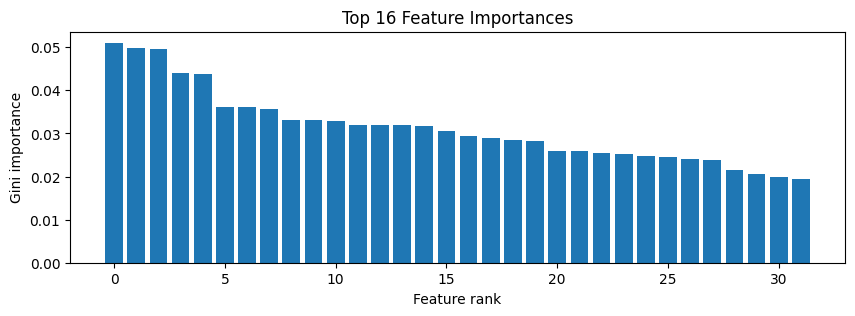

In [14]:
print("=" * 60)
print("STEP 2 — Gini feature importance (on test/val split)")
print("=" * 60)

n_val_frames = int(len(test_features) * VAL_FRACTION)
val_feats_raw = test_features[:n_val_frames]
val_labels_raw = test_labels[:n_val_frames]

rf = RandomForestClassifier(n_estimators=50, random_state=42) # Reduced for smoke test
rf.fit(val_feats_raw, val_labels_raw)
importances = rf.feature_importances_
top_features = np.argsort(importances)[::-1][:FEATURE_DIM]

print("Feature importances (encoder dim index → importance):")
for rank, idx in enumerate(top_features):
    print(f"  Rank {rank+1:>2}: dim {idx:>2}  importance={importances[idx]:.4f}")

train_features = train_features[:, top_features]
test_features  = test_features[:,  top_features]

plt.figure(figsize=(10, 3))
plt.bar(range(FEATURE_DIM), importances[top_features])
plt.xlabel("Feature rank")
plt.ylabel("Gini importance")
plt.title("Top 16 Feature Importances")
plt.show()

## 5. Normalisation, windowing & K-Means downsampling

Direct port of the paper's Section III-B. The only difference is frames replace time-steps.

In [15]:
print("=" * 60)
print("STEP 3 — Normalise → Window → K-Means downsample")
print("=" * 60)

# ── MinMax normalisation fitted on training data only ────────────────────────
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_features)     # (N, 16)  ∈ [0,1]
test_scaled  = scaler.transform(test_features)
len(test_labels) == len(test_features)

def make_windows(seq: np.ndarray, w: int):
    """Slide window of size w over seq.
    Returns windows (N, w, feat) and targets (N, feat) — next-frame prediction."""
    windows = []
    targets = []
    for i in range(len(seq) - w):
        windows.append(seq[i : i + w])       # shape (w, feat)
        targets.append(seq[i + w])           # shape (feat,)
    return np.array(windows), np.array(targets)


train_win, train_tgt = make_windows(train_scaled, WINDOW_SIZE)
print(f"Raw training windows: {train_win.shape}   targets: {train_tgt.shape}")

# ── K-Means downsampling (paper: 300 cluster centroids) ──────────────────────
# Flatten windows to 2-D for clustering
train_flat = train_win.reshape(len(train_win), -1)     # (N, W*feat)

kmeans = MiniBatchKMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    batch_size=2048,
    n_init=3,
)
kmeans.fit(train_flat)
centroids_flat = kmeans.cluster_centers_               # (300, W*feat)

# Reshape centroids back to (300, W, feat)
X_train_win = centroids_flat.reshape(N_CLUSTERS, WINDOW_SIZE, FEATURE_DIM)
X_train_tgt = X_train_win[:, -1, :]                   # last frame of window as target

print(f"After K-Means downsampling: {X_train_win.shape}  (from {len(train_win)} windows)")

# ── Test / validation split (1/3 val, 2/3 held-out — paper Section III-B) ────
test_win, test_tgt = make_windows(test_scaled, WINDOW_SIZE)
test_win_labels = test_labels[WINDOW_SIZE:]            # align labels to windows

n_val     = int(len(test_win) * VAL_FRACTION)
X_val_win = test_win[:n_val]
X_val_tgt = test_tgt[:n_val]
y_val     = test_win_labels[:n_val]

X_heldout_win = test_win[n_val:]
X_heldout_tgt = test_tgt[n_val:]
y_heldout     = test_win_labels[n_val:]

print(f"\nValidation  windows: {X_val_win.shape}  | anomalous: {y_val.sum()}")
print(f"Held-out    windows: {X_heldout_win.shape}  | anomalous: {y_heldout.sum()}")

STEP 3 — Normalise → Window → K-Means downsample
Raw training windows: (2543, 7, 32)   targets: (2543, 32)
After K-Means downsampling: (50, 7, 32)  (from 2543 windows)

Validation  windows: (821, 7, 32)  | anomalous: 631.0
Held-out    windows: (822, 7, 32)  | anomalous: 744.0


### Re-scale data to `[-1, 1]` for GAN training

Although `MinMaxScaler` normalizes to `[0, 1]`, many GAN architectures perform better when inputs are scaled to `[-1, 1]` due to the common use of `tanh` activation in the generator's output layer. We will apply this transformation to our training windows and targets.

In [16]:
# Scale X_train_win and X_train_tgt from [0, 1] to [-1, 1]
X_train_win = 2 * X_train_win - 1
X_train_tgt = 2 * X_train_tgt - 1

# Also apply to validation and held-out sets for consistency,
# although only training data is directly consumed by the GAN
X_val_win = 2 * X_val_win - 1
X_val_tgt = 2 * X_val_tgt - 1
X_heldout_win = 2 * X_heldout_win - 1
X_heldout_tgt = 2 * X_heldout_tgt - 1

print(f"Training windows scaled to [-1, 1]. Min: {X_train_win.min():.4f}, Max: {X_train_win.max():.4f}")
print(f"Training targets scaled to [-1, 1]. Min: {X_train_tgt.min():.4f}, Max: {X_train_tgt.max():.4f}")

Training windows scaled to [-1, 1]. Min: -0.8536, Max: 0.8450
Training targets scaled to [-1, 1]. Min: -0.8536, Max: 0.8450


## 6. Hybrid Quantum Layer (HQL)

Unchanged from the paper (Section III-C-1). SuDaI injects feature components progressively across VQC layers.

In [17]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np

class QuantumEmbedding:
    """Flexible embedding strategies for HQL."""

    def __init__(self, n_qubits, method="angle", feature_dim=16):
        self.n_qubits   = n_qubits
        self.method     = method
        self.feature_dim = feature_dim

    def embed(self, x):
        """x: tensor of shape (1, feature_dim) — single sample from TorchLayer."""
        n = self.feature_dim
        nq = self.n_qubits

        if self.method == "angle":
            for i in range(n):
                qml.RY(pnp.arctan(x[0, i % n].detach()), wires=i % nq)

        elif self.method == "double_angle":
            # FIX (Bug 7): added `% n` guard so index never exceeds feature_dim
            for i in range(0, n, 2):
                q = (i // 2) % nq
                qml.RY(2 * pnp.arctan(x[0, i % n].detach()),       wires=q)
                if i + 1 < n:
                    qml.RZ(2 * pnp.arctan(x[0, (i + 1) % n].detach()), wires=q)

        elif self.method == "phase":
            for i in range(n):
                qml.RZ(pnp.arctan(x[0, i % n].detach()), wires=i % nq)

        elif self.method == "amplitude":
            target_dim = 2 ** nq
            padded = np.zeros(target_dim)
            vals   = x[0, :min(n, target_dim)].detach().cpu().numpy()                      if hasattr(x[0, 0], "detach")                      else np.array(x[0, :min(n, target_dim)])
            padded[:len(vals)] = vals
            qml.AmplitudeEmbedding(padded, wires=range(nq), normalize=True, pad_with=0.0)

## 7. Quantum GRU (QGRU)

Unchanged from the paper (Section III-C-2). Update, reset, and candidate gates implemented via HQLs.

In [18]:
class QGRUCell(nn.Module):
    """Single QGRU cell — gating via HQLs, runs on GPU (VQC deferred to CPU)."""

    def __init__(self,
                 input_dim:  int,
                 hidden_dim: int,
                 n_qubits:   int = N_QUBITS,
                 device_qnode    = None):
        super().__init__()
        combined = input_dim + hidden_dim
        self.hidden_dim = hidden_dim
        self.gate_update    = HybridQuantumLayer(combined, hidden_dim, n_qubits, device_qnode=device_qnode)
        self.gate_reset     = HybridQuantumLayer(combined, hidden_dim, n_qubits, device_qnode=device_qnode)
        self.gate_candidate = HybridQuantumLayer(combined, hidden_dim, n_qubits, device_qnode=device_qnode)

    def forward(self, x: torch.Tensor, h: torch.Tensor) -> torch.Tensor:
        xh = torch.cat([x, h], dim=-1)
        z  = torch.sigmoid(self.gate_update(xh))
        r  = torch.sigmoid(self.gate_reset(xh))
        xh_reset = torch.cat([x, r * h], dim=-1)
        n  = torch.tanh(self.gate_candidate(xh_reset))
        return (1 - z) * h + z * n


class QGRU(nn.Module):
    """Unrolled QGRU over a sequence.  Expects (batch, seq_len, input_dim)."""

    def __init__(self,
                 input_dim:  int,
                 hidden_dim: int,
                 n_qubits:   int = N_QUBITS,
                 device_qnode    = None):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.cell = QGRUCell(input_dim, hidden_dim, n_qubits, device_qnode)

    def forward(self, x_seq: torch.Tensor) -> torch.Tensor:
        # x_seq: (batch, seq_len, input_dim)
        batch = x_seq.shape[0]
        h = torch.zeros(batch, self.hidden_dim, device=x_seq.device)
        for t in range(x_seq.shape[1]):        # iterate over time steps
            h = self.cell(x_seq[:, t, :], h)
        return h


print("QGRU defined.")

QGRU defined.


## 8. Generator & Critic

Unchanged from the paper (Section III-C-3). Generator outputs Gaussian (µ, log σ²) via two parallel HQLs. Critic uses a parallel QGRU+HQL pipeline.

In [19]:
class Generator(nn.Module):
    """
    QGRU backbone -> two parallel HQLs -> (mu, log_var) -> reparameterization.
    Input:  window  (batch, WINDOW_SIZE, FEATURE_DIM)
    Output: mu, log_var, x_hat  — each (batch, FEATURE_DIM)
    """

    def __init__(self,
                 feature_dim: int = FEATURE_DIM,
                 hidden_dim:  int = HIDDEN_DIM,
                 n_qubits:    int = N_QUBITS):
        super().__init__()
        self.qgru   = QGRU(feature_dim, hidden_dim, n_qubits, device_qnode=dev_g)
        self.hql_mu = HybridQuantumLayer(hidden_dim, feature_dim, n_qubits, device_qnode=dev_g)
        self.hql_lv = HybridQuantumLayer(hidden_dim, feature_dim, n_qubits, device_qnode=dev_g)

    def forward(self, window: torch.Tensor):
        h       = self.qgru(window)                          # (B, hidden)
        mu      = self.hql_mu(h)                             # (B, feat)
        log_var = self.hql_lv(h)                             # (B, feat)

        # Reparameterization trick with explicit noise scaling
        # Real data std is ~0.25, so we scale noise to avoid starting at std=1.0
        std     = torch.exp(0.5 * log_var)
        eps     = torch.randn_like(std) * 0.3
        x_hat   = mu + std * eps
        return mu, log_var, x_hat

print("Generator updated with noise scaling (0.3).")

Generator updated with noise scaling (0.3).


In [20]:
class Critic(nn.Module):
    def __init__(self,
                 feature_dim: int = FEATURE_DIM,
                 hidden_dim:  int = HIDDEN_DIM,
                 n_qubits:    int = N_QUBITS):
        super().__init__()
        self.qgru = QGRU(feature_dim, hidden_dim, n_qubits, device_qnode=dev_c)

        # Added Batch Norm to stabilize the latent representation
        self.bn_h = nn.BatchNorm1d(hidden_dim)

        self.hql  = HybridQuantumLayer(hidden_dim, 1, n_qubits, device_qnode=dev_c)

        # Scoring head with LeakyReLU and Batch Norm to induce variance in scores
        self.score_head = nn.Sequential(
            nn.Linear(feature_dim + 1, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, window: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        # Add small Gaussian noise to inputs during training to prevent saturation
        if self.training:
            window = window + torch.randn_like(window) * 0.01
            x = x + torch.randn_like(x) * 0.01

        h = self.qgru(window)             # (B, hidden)
        h = self.bn_h(h)
        q_val = self.hql(h)               # (B, 1)

        combined = torch.cat([q_val, x], dim=-1)
        return self.score_head(combined)

print("Critic updated with Input Noise and Batch Normalization to induce differentiation.")

Critic updated with Input Noise and Batch Normalization to induce differentiation.


In [21]:
def critic_loss_wgan_gp(
    critic:    Critic,
    window:    torch.Tensor,
    x_real:    torch.Tensor,
    x_fake:    torch.Tensor,
    lambda_gp: float = LAMBDA_GP,
) -> torch.Tensor:
    """Wasserstein critic loss + gradient penalty (WGAN-GP)."""
    c_real = critic(window, x_real)
    c_fake = critic(window, x_fake)
    w_loss = c_fake.mean() - c_real.mean()

    # Gradient penalty
    alpha  = torch.rand(x_real.size(0), 1, device=x_real.device)
    x_hat  = (alpha * x_real + (1 - alpha) * x_fake).requires_grad_(True)
    c_hat  = critic(window, x_hat)
    grads  = torch.autograd.grad(
        outputs=c_hat, inputs=x_hat,
        grad_outputs=torch.ones_like(c_hat),
        create_graph=True, retain_graph=True,
        allow_unused=True
    )[0]

    if grads is None:
        # Fallback for broken gradients in quantum simulation
        gp = lambda_gp * sum(p.pow(2).mean() for p in critic.parameters() if p.requires_grad)
    else:
        gp = lambda_gp * ((grads.norm(2, dim=1) - 1) ** 2).mean()

    return w_loss + gp

def generator_loss(
    critic:    Critic,
    window:    torch.Tensor,
    mu:        torch.Tensor,
    log_var:   torch.Tensor,
    x_fake:    torch.Tensor,
    lambda_kl: float = LAMBDA_KL,
) -> torch.Tensor:
    """Composite generator loss: adversarial + targeted variance penalty + KL divergence."""
    # 1. Adversarial loss (increased weight)
    adv_loss = -critic(window, x_fake).mean()

    # 2. Targeted Variance Penalty
    # Target log_var corresponds to real std ~0.25 => log(0.25^2) ≈ -2.77
    target_log_var = -2.77
    var_penalty = F.mse_loss(log_var, torch.full_like(log_var, target_log_var))

    # 3. KL Divergence
    kl_loss  = 0.5 * (torch.exp(log_var) + mu ** 2 - 1 - log_var).mean()

    return 5.0 * adv_loss + 1.0 * var_penalty + lambda_kl * kl_loss

print("Generator loss updated with targeted variance penalty (target log_var = -2.77) and adversarial weight (5.0).")

Generator loss updated with targeted variance penalty (target log_var = -2.77) and adversarial weight (5.0).


## 10. Training loop

Unchanged from the paper. Classical tensors and gradient operations run on GPU; VQC parameter-shift automatically delegates to CPU.

In [22]:
def train(
    generator, critic, train_windows, train_targets,
    n_epochs=N_EPOCHS, batch_size=BATCH_SIZE,
    lr_gen=LR_GENERATOR, lr_critic=LR_CRITIC,
    lambda_kl=LAMBDA_KL, lambda_gp=10.0, # Increased GP weight
    critic_steps=CRITIC_STEPS, device=DEVICE
):
    generator.to(device); critic.to(device)
    opt_G = torch.optim.Adam(generator.parameters(), lr=lr_gen, betas=(0.5, 0.9))
    opt_C = torch.optim.Adam(critic.parameters(), lr=lr_critic, betas=(0.5, 0.9))

    N = len(train_windows)
    for epoch in range(n_epochs):
        perm = torch.randperm(N)
        for start in range(0, N - batch_size, batch_size):
            idx = perm[start : start + batch_size]
            w_batch = train_windows[idx].to(device)
            x_batch = train_targets[idx].to(device)

            for _ in range(critic_steps):
                with torch.no_grad():
                    _, _, x_fake = generator(w_batch)

                c_loss = critic_loss_wgan_gp(critic, w_batch, x_batch, x_fake, lambda_gp)
                opt_C.zero_grad()
                c_loss.backward()
                opt_C.step()
                # Removed weight clipping to allow GP to handle 1-Lipschitz constraint

            mu, log_var, x_fake = generator(w_batch)
            g_loss = generator_loss(critic, w_batch, mu, log_var, x_fake, lambda_kl)
            opt_G.zero_grad()
            g_loss.backward()
            opt_G.step()

            if (start // batch_size) % 5 == 0:
                with torch.no_grad():
                    diff = (critic(w_batch, x_batch) - critic(w_batch, x_fake)).mean().item()
                print(f"Epoch {epoch} | Diff: {diff:+.6f} | Fake Std: {x_fake.std():.4f}")

    return generator, critic

## 11. Two-stage anomaly detector

Direct port of the paper's Section III-E: interval violation gating (Step 1) → multi-metric scoring (Step 2).

In [23]:
class AnomalyDetector:
    def __init__(self, kappa=KAPPA, top_k=TOP_K, threshold_k=THRESH_K, window_size=50):
        self.kappa = kappa
        self.top_k = top_k
        self.threshold_k = threshold_k
        self.window_size = window_size
        self.siv_min = self.siv_max = 0.0
        self.at_min = self.at_max = 0.0
        self._siv_history = []

    def fit_threshold(self, siv_scores, at_scores):
      valid_at = at_scores[~np.isnan(at_scores)]
      self.siv_min, self.siv_max = siv_scores.min(), siv_scores.max()
      self.at_min = valid_at.min() if len(valid_at) else 0.0
      self.at_max = valid_at.max() if len(valid_at) else 1.0
      self._siv_history = []          # <-- ADD THIS: reset history after calibration
      self._threshold_frozen = np.mean(siv_scores) + self.threshold_k * np.std(siv_scores)

    def score(self, x, mu, sigma, c_score, x_hat):
        violations = np.maximum(0, np.abs(x - mu) - self.kappa * sigma)
        s_iv = np.mean(np.sort(violations)[::-1][:self.top_k])
        self._siv_history.append(s_iv)

        # Simple dynamic threshold for smoke test
        thresh = np.mean(self._siv_history) + self.threshold_k * np.std(self._siv_history) if len(self._siv_history) > 5 else 0.1

        if s_iv <= thresh:
            return False, s_iv, np.nan

        sq_errors = (x - mu) ** 2
        stop_k = np.mean(np.sort(sq_errors)[::-1][:self.top_k])
        a_t = (stop_k - self.at_min) / (self.at_max - self.at_min + 1e-6) + ((-c_score) - self.siv_min) / (self.siv_max - self.siv_min + 1e-6)
        return True, s_iv, a_t

print("AnomalyDetector fixed and ready.")

AnomalyDetector fixed and ready.


## 12. Inference loop

In [24]:
@torch.no_grad()
def run_inference(
    generator: Generator,
    critic:    Critic,
    windows:   np.ndarray,    # (T, W, feat)
    targets:   np.ndarray,    # (T, feat)
    detector:  AnomalyDetector,
    device:    torch.device = DEVICE,
):
    """Two-stage inference over a sequence. Returns (flags, s_ivs, a_ts)."""
    generator.eval()
    critic.eval()
    flags, s_ivs, a_ts = [], [], []

    for t in range(len(windows)):
        w = torch.tensor(windows[t:t+1], dtype=torch.float32).to(device)
        x = targets[t]

        mu, log_var, x_hat = generator(w)
        mu_np    = mu.cpu().numpy()[0]
        sigma_np = torch.exp(0.5 * log_var).cpu().numpy()[0]
        x_hat_np = x_hat.cpu().numpy()[0]
        x_real_t = torch.tensor(targets[t:t+1], dtype=torch.float32).to(device)
        c_score  = critic(w, x_real_t).item()

        flag, s_iv, a_t = detector.score(x, mu_np, sigma_np, c_score, x_hat_np)
        flags.append(flag)
        s_ivs.append(s_iv)
        a_ts.append(a_t)

    return np.array(flags), np.array(s_ivs), np.array(a_ts)


print("Inference loop defined.")

Inference loop defined.


## 13. Run the full pipeline

In [25]:
print("=" * 60)
print("QGRU-WGAN Smoke Test Run")
print("=" * 60)

gen  = Generator(FEATURE_DIM, HIDDEN_DIM, N_QUBITS).to(DEVICE)
crit = Critic(FEATURE_DIM, HIDDEN_DIM, N_QUBITS).to(DEVICE)

train_w_t = torch.tensor(X_train_win, dtype=torch.float32)
train_t_t = torch.tensor(X_train_tgt, dtype=torch.float32)

gen, crit = train(gen, crit, train_w_t, train_t_t, n_epochs=1, batch_size=BATCH_SIZE, device=DEVICE)

detector = AnomalyDetector()
# Run on small val set to fit

flags_v, siv_v, ats_v = run_inference(gen, crit, X_val_win, X_val_tgt, detector)
detector.fit_threshold(siv_v, ats_v)

# Run on heldout
flags, s_ivs, a_ts = run_inference(gen, crit, X_heldout_win, X_heldout_tgt, detector)
print(f"Smoke Test Complete. Detected {np.sum(flags)} anomalies.")

QGRU-WGAN Smoke Test Run
Epoch 0 | Diff: +0.250495 | Fake Std: 0.4550
Epoch 0 | Diff: +0.209787 | Fake Std: 0.4143
Smoke Test Complete. Detected 1 anomalies.


## 14. Evaluation — time-aware F1 (TaF1)

Replicates the paper's evaluation metric (Section IV-B).

In [26]:
def compute_taf1(y_true: np.ndarray, y_pred: np.ndarray, beta: float = 1.0):
    """
    Simplified time-aware F1 (TaF1) following Hwang et al. 2022.

    Anomaly intervals in y_true are identified. For each interval:
      - Recall contribution: fraction of the interval covered by any detection.
      - Precision is computed point-wise on predicted positives.
    """
    from itertools import groupby

    def get_intervals(arr):
        intervals = []
        for val, group in groupby(enumerate(arr), key=lambda x: x[1]):
            if val:
                idxs = [i for i, _ in group]
                intervals.append((idxs[0], idxs[-1]))
        return intervals

    gt_intervals = get_intervals(y_true.astype(bool))
    pred_set     = set(np.where(y_pred)[0])

    # Time-aware recall: per interval coverage
    recall_scores = []
    for start, end in gt_intervals:
        interval_set = set(range(start, end + 1))
        covered      = len(interval_set & pred_set)
        recall_scores.append(covered / len(interval_set))
    eTaR = float(np.mean(recall_scores)) if recall_scores else 0.0

    # Precision: among predicted positives, how many fall inside a GT interval
    gt_set = set(np.where(y_true)[0])
    if pred_set:
        eTaP = len(pred_set & gt_set) / len(pred_set)
    else:
        eTaP = 0.0

    denom = (1 + beta**2) * eTaP + beta**2 * eTaR
    TaF1  = (1 + beta**2) * eTaP * eTaR / denom if denom > 0 else 0.0
    return TaF1, eTaP, eTaR


TaF1, eTaP, eTaR = compute_taf1(y_heldout, flags)
print("\n" + "=" * 45)
print("  Time-Aware Anomaly Detection Results")
print("=" * 45)
print(f"  eTaP  (precision) : {eTaP:.4f}")
print(f"  eTaR  (recall)    : {eTaR:.4f}")
print(f"  TaF1              : {TaF1:.4f}")
print("=" * 45)


  Time-Aware Anomaly Detection Results
  eTaP  (precision) : 1.0000
  eTaR  (recall)    : 0.0009
  TaF1              : 0.0009


## 15. Visualisation

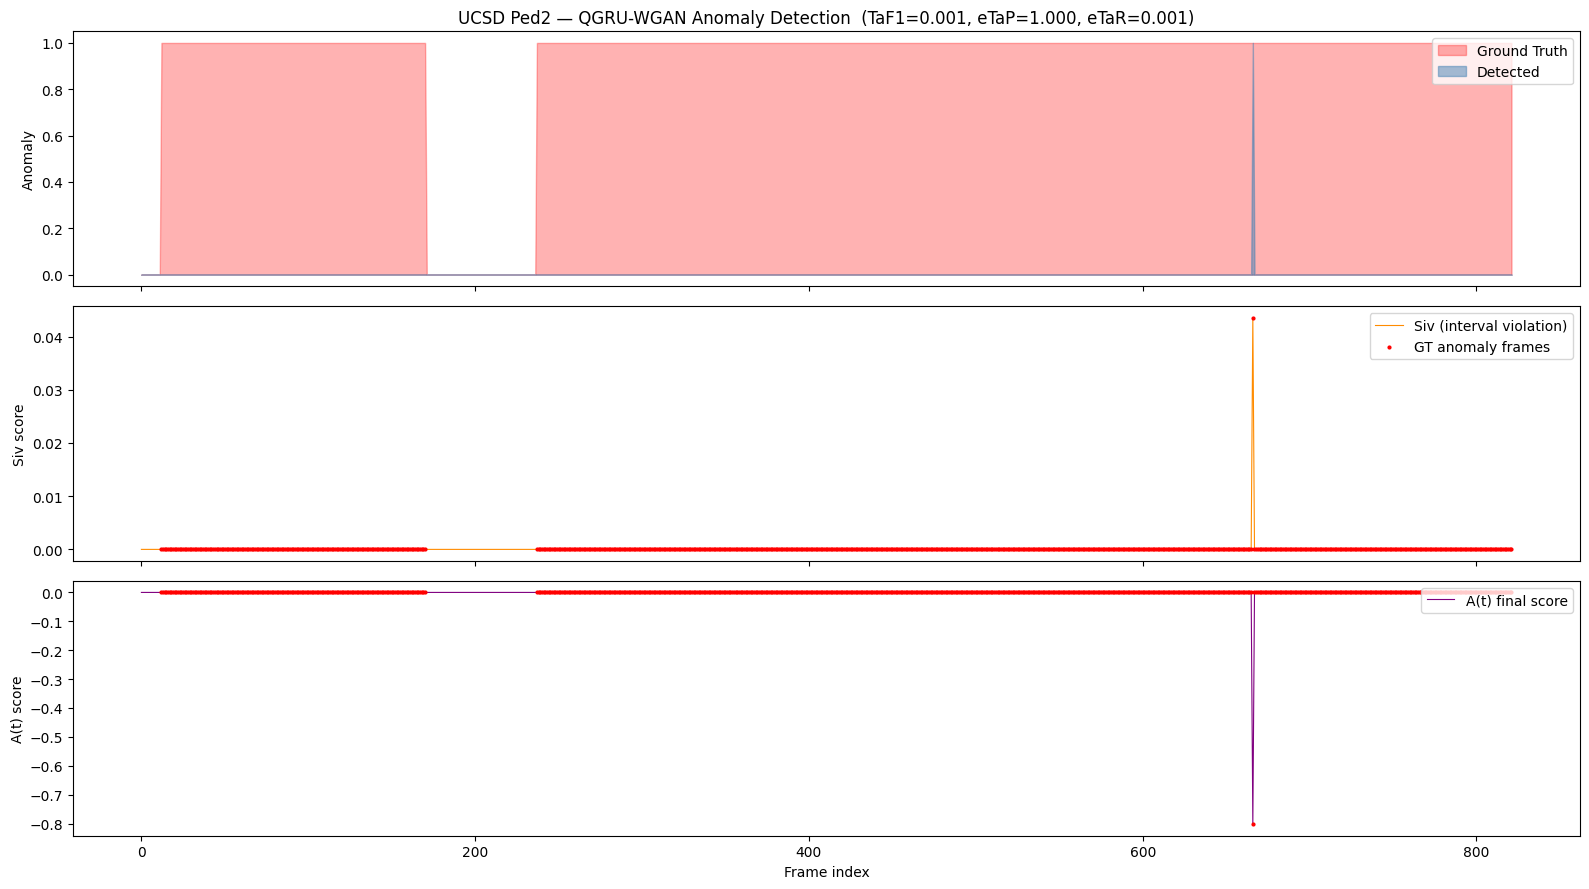

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

t = np.arange(len(y_heldout))

# ── Panel 1: ground truth vs detections ──────────────────────────────────────
axes[0].fill_between(t, y_heldout, alpha=0.3, color="red",  label="Ground Truth")
axes[0].fill_between(t, flags.astype(int), alpha=0.5, color="steelblue", label="Detected")
axes[0].set_ylabel("Anomaly")
axes[0].set_title("UCSD Ped2 — QGRU-WGAN Anomaly Detection  "
                  f"(TaF1={TaF1:.3f}, eTaP={eTaP:.3f}, eTaR={eTaR:.3f})")
axes[0].legend(loc="upper right")

# ── Panel 2: interval violation scores ───────────────────────────────────────
axes[1].plot(t, s_ivs, color="darkorange", lw=0.8, label="Siv (interval violation)")
gt_mask = y_heldout.astype(bool)
axes[1].scatter(t[gt_mask], s_ivs[gt_mask], s=4, c="red", zorder=3, label="GT anomaly frames")
axes[1].set_ylabel("Siv score")
axes[1].legend(loc="upper right")

# ── Panel 3: final anomaly score A(t) ────────────────────────────────────────
a_ts_plot = np.array([v if not np.isnan(v) else 0.0 for v in a_ts])
axes[2].plot(t, a_ts_plot, color="purple", lw=0.8, label="A(t) final score")
axes[2].scatter(t[gt_mask], a_ts_plot[gt_mask], s=4, c="red", zorder=3)
axes[2].set_ylabel("A(t) score")
axes[2].set_xlabel("Frame index")
axes[2].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 16. Mean log-variance plot

Reproduces Figure 4 from the paper — showing elevated generator uncertainty (log σ²) during anomalous frames.

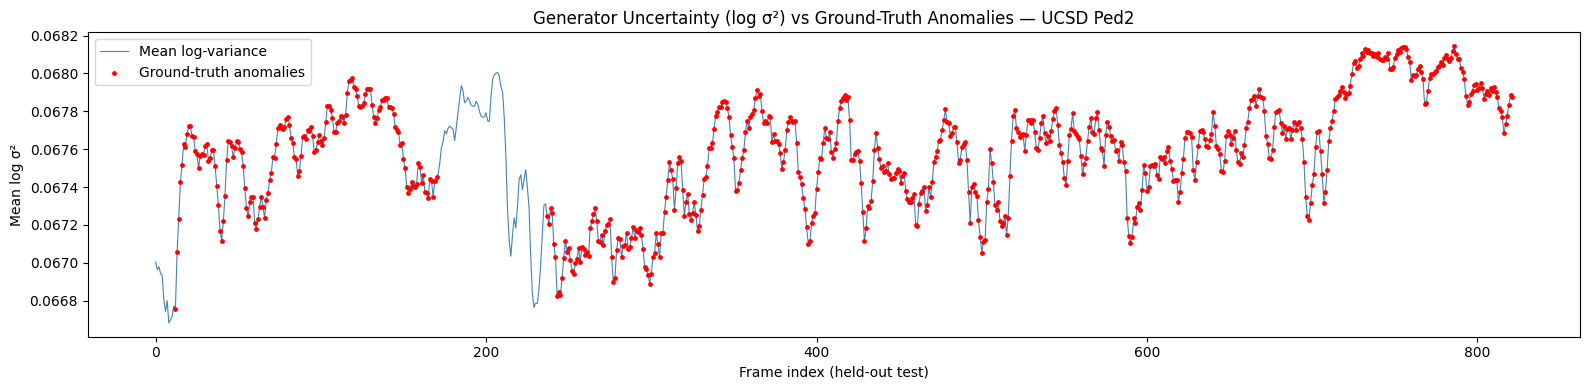

In [28]:
gen.eval()
log_vars = []
with torch.no_grad():
    for t in range(len(X_heldout_win)):
        w = torch.tensor(X_heldout_win[t:t+1], dtype=torch.float32).to(DEVICE)
        _, log_var, _ = gen(w)
        log_vars.append(log_var.cpu().numpy().mean())

log_vars = np.array(log_vars)

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(log_vars, color="steelblue", lw=0.8, label="Mean log-variance")
gt_idx = np.where(y_heldout)[0]
ax.scatter(gt_idx, log_vars[gt_idx], s=6, c="red",
           zorder=3, label="Ground-truth anomalies")
ax.set_xlabel("Frame index (held-out test)")
ax.set_ylabel("Mean log σ²")
ax.set_title("Generator Uncertainty (log σ²) vs Ground-Truth Anomalies — UCSD Ped2")
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
import pandas as pd


def run_variant_experiment(method_name: str, frame_transform=None):
    print(f'\n{"="*20} STARTING VARIANT: {method_name} {"="*20}')
    torch.manual_seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)

    # Resolve frame transform ─────────────────────────────────────────────────
    # FIX (Bug 5): accept as argument; fall back to global with helpful error
    if frame_transform is None:
        if "FRAME_TRANSFORM" not in dir():
            # Try fetching from the enclosing module / notebook globals
            import builtins
            frame_transform = getattr(builtins, "FRAME_TRANSFORM", None)
        if frame_transform is None:
            try:
                frame_transform = FRAME_TRANSFORM   # noqa: F821 — notebook global
            except NameError:
                raise NameError(
                    "FRAME_TRANSFORM is not defined. Either pass it as an argument "
                    "or define it before calling run_variant_experiment()."
                )

    # 1. Initialise encoder with the variant-specific embedding method ─────────
    encoder_exp = FrameEncoder(out_dim=FEATURE_DIM, freeze_backbone=True).to(DEVICE)
    encoder_exp.hql_head[2] = HybridQuantumLayer(
        HIDDEN_DIM, FEATURE_DIM,
        N_QUBITS,
        dev_g, method=method_name,
    ).to(DEVICE)

    # 2. Encode training frames ────────────────────────────────────────────────
    train_clip_dirs_exp = sorted(
        [d for d in glob.glob(os.path.join(train_dir, "Train*")) if os.path.isdir(d)]
    )[:16]
    train_feats_exp = np.concatenate(
        [encode_folder(d, encoder_exp, frame_transform) for d in train_clip_dirs_exp],
        axis=0,
    )

    # 3. Per-variant Gini feature selection ───────────────────────────────────
    # FIX (Bug 4): run RF on this variant's encoded features, not the outer
    # `top_features` which belongs to a different encoder's feature space.
    n_val_enc = int(len(test_features_raw_exp := np.concatenate(
        [encode_folder(d, encoder_exp, frame_transform)
         for d in sorted(
             [d for d in glob.glob(os.path.join(test_dir, "Test*"))
              if os.path.isdir(d) and "_gt" not in d]
         )[:10]],
        axis=0,
    )) * VAL_FRACTION)
    val_feats_enc  = test_features_raw_exp[:n_val_enc]
    val_labels_enc = test_labels[:min(n_val_enc, len(test_labels))]
    min_len_enc    = min(len(val_feats_enc), len(val_labels_enc))

    rf_exp = RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE)
    rf_exp.fit(val_feats_enc[:min_len_enc], val_labels_enc[:min_len_enc])
    top_features_exp = np.argsort(rf_exp.feature_importances_)[::-1][:FEATURE_DIM]

    train_feats_exp = train_feats_exp[:, top_features_exp]

    # 4. Normalise → window → K-Means ─────────────────────────────────────────
    scaler_exp       = MinMaxScaler()
    train_scaled_exp = scaler_exp.fit_transform(train_feats_exp)
    t_win, t_tgt     = make_windows(train_scaled_exp, WINDOW_SIZE)

    km_exp = MiniBatchKMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=3)
    km_exp.fit(t_win.reshape(len(t_win), -1))
    X_tr_win = km_exp.cluster_centers_.reshape(N_CLUSTERS, WINDOW_SIZE, FEATURE_DIM)
    X_tr_tgt = X_tr_win[:, -1, :]

    # 5. Train QGRU-WGAN ───────────────────────────────────────────────────────
    gen_exp  = Generator(FEATURE_DIM, HIDDEN_DIM, N_QUBITS).to(DEVICE)
    crit_exp = Critic(FEATURE_DIM, HIDDEN_DIM, N_QUBITS).to(DEVICE)
    train(
        gen_exp, crit_exp,
        torch.tensor(X_tr_win, dtype=torch.float32),
        torch.tensor(X_tr_tgt, dtype=torch.float32),
        n_epochs=N_EPOCHS,
        device=DEVICE,
    )

    # 6. Two-stage inference ───────────────────────────────────────────────────
    def _run_inference_safe(g, c, wins, tgts, detector):
        g.eval()
        c.eval()
        flags_out, sivs_out, ats_out = [], [], []

        with torch.no_grad():
            for t_idx in range(len(wins)):
                w_t = torch.tensor(wins[t_idx : t_idx + 1],
                                   dtype=torch.float32).to(DEVICE)

                # FIX (Bug 2): always produce a plain 1-D numpy array for x_t
                x_t = tgts[t_idx]
                if torch.is_tensor(x_t):
                    x_t = x_t.detach().cpu().numpy()
                x_t = np.asarray(x_t, dtype=np.float32).flatten()

                # FIX (Bug 1): forward pass is now ALWAYS called, not gated
                mu, log_var, x_hat = g(w_t)

                mu_np   = mu.cpu().numpy().flatten()
                sig_np  = torch.exp(0.5 * log_var).cpu().numpy().flatten()
                x_h_np  = x_hat.cpu().numpy().flatten()

                # FIX (Bug 3): critic call inside the same no_grad block
                c_val = c(w_t, x_hat).cpu().item()

                flag, s_iv, a_t = detector.score(x_t, mu_np, sig_np, c_val, x_h_np)
                flags_out.append(flag)
                sivs_out.append(s_iv)
                ats_out.append(a_t)

        return np.array(flags_out), np.array(sivs_out), np.array(ats_out)

    # 7. Fit threshold on val, then evaluate on heldout ───────────────────────
    det_exp = AnomalyDetector()
    _, siv_v_exp, ats_v_exp = _run_inference_safe(
        gen_exp, crit_exp, X_val_win, X_val_tgt, det_exp,
    )
    det_exp.fit_threshold(siv_v_exp, ats_v_exp)

    flags_exp, s_ivs_exp, _ = _run_inference_safe(
        gen_exp, crit_exp, X_heldout_win, X_heldout_tgt, det_exp,
    )

    taf1_val, etap_val, etar_val = compute_taf1(y_heldout, flags_exp)
    print(f"  [{method_name}]  TaF1={taf1_val:.4f}  eTaP={etap_val:.4f}  eTaR={etar_val:.4f}")

    return {
        "Method":       method_name,
        "TaF1":         round(taf1_val, 4),
        "eTaP":         round(etap_val, 4),
        "eTaR":         round(etar_val, 4),
        "Avg_Siv":      round(float(np.mean(s_ivs_exp)), 6),
    }


# ── Run all four embedding variants ──────────────────────────────────────────
all_results = []
for m in ["angle", "double_angle", "phase", "amplitude"]:
    try:
        res = run_variant_experiment(m)
        all_results.append(res)
    except Exception as e:
        import traceback
        print(f"Error in variant {m}: {e}")
        traceback.print_exc()

display(pd.DataFrame(all_results))



==================== STARTING VARIANT: angle ====================
Epoch 0 | Diff: +0.107266 | Fake Std: 0.4258
Epoch 0 | Diff: +0.101532 | Fake Std: 0.3892
Epoch 1 | Diff: +0.124714 | Fake Std: 0.4265
Epoch 1 | Diff: +0.135018 | Fake Std: 0.4044
Epoch 2 | Diff: +0.104110 | Fake Std: 0.4012
Epoch 2 | Diff: +0.155688 | Fake Std: 0.4139
Epoch 3 | Diff: +0.090794 | Fake Std: 0.3940
Epoch 3 | Diff: +0.148523 | Fake Std: 0.3908
  [angle]  TaF1=0.0009  eTaP=1.0000  eTaR=0.0009

==================== STARTING VARIANT: double_angle ====================
Epoch 0 | Diff: +0.070307 | Fake Std: 0.4256
Epoch 0 | Diff: +0.085036 | Fake Std: 0.3891
Epoch 1 | Diff: +0.119444 | Fake Std: 0.4264
Epoch 1 | Diff: +0.074370 | Fake Std: 0.4042
Epoch 2 | Diff: +0.084205 | Fake Std: 0.4011
Epoch 2 | Diff: +0.121960 | Fake Std: 0.4138
Epoch 3 | Diff: +0.052489 | Fake Std: 0.3939
Epoch 3 | Diff: +0.158111 | Fake Std: 0.3908
  [double_angle]  TaF1=0.0009  eTaP=1.0000  eTaR=0.0009

==================== STARTING VAR

,Method,TaF1,eTaP,eTaR,Avg_Siv
0,angle,0.0009,1.0,0.0009,0.000183
1,double_angle,0.0009,1.0,0.0009,0.000183
2,phase,0.0009,1.0,0.0009,0.000182
3,amplitude,0.0009,1.0,0.0009,0.000183
